In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rusterize as _rusterize_pkg
import seaborn as sns
import xarray as xr
from rasterix.rasterize import geometry_mask

from srm import catalog
from srm.config import _icechunk_storage_for_path
from srm.qa_flags import discover_leaves, parse_tag

In [2]:
SUMMARY_CSV = "qa_flag_summary.csv"

# A. Define what data arrays exist to traverse

In [3]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [4]:
GCMS = ["CESM2-WACCM"]

# BRANCH = "full-regional-run-issue-534"
# ROOT_DIR = "s3://carbonplan-scratch/srm/output/qa/"
# STORE_SUBSET_BOUNDS = (-38.0, -19.0, 13.0, 36.0)
# STORE_SUBSET_ID = ArtifactCache._get_subset_id(STORE_SUBSET_BOUNDS)

BRANCH = "v0.13.0"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

In [5]:
[_, tags, _, _, _, tags_np] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID
)

opened 1/1 stores on branch 'v0.13.0': CESM2-WACCM
71 leaves across 1 GCMs


In [ ]:
repos: dict[str, icechunk.Repository] = {}
for gcm in GCMS:
    repos[gcm] = icechunk.Repository.open(
        _icechunk_storage_for_path(f"{ROOT_DIR}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk")
    )

# B. Create CSV summarizing flag prevalence

In [7]:
ocean_mask_geoparquet = catalog.get("ocean-mask")

In [8]:
# Claude-generated patch to get the geoparquet -> gridded mask to work
_original_rusterize = _rusterize_pkg.rusterize


def _rusterize_patched(*args, **kwargs):
    if kwargs.get("res") is not None and kwargs.get("out_shape") is not None:
        kwargs = dict(kwargs)
        kwargs.pop("res")
    return _original_rusterize(*args, **kwargs)


_rusterize_pkg.rusterize = _rusterize_patched

In [10]:
tag = tags[0]
[gcm, var, scenario, ens] = parse_tag(tag)
example_flags = xr.open_zarr(
    repos[gcm].readonly_session(BRANCH).store, group=f"{scenario}/{var}/{ens}", consolidated=False
)
target_grid_da = example_flags["flag_time_invariant"]

# rusterize requires lat sorted descending; reorder target_grid_da first if needed
template = target_grid_da.sortby("lat", ascending=False).proj.assign_crs(spatial_ref="epsg:4326")

land_mask = ~geometry_mask(
    template,
    ocean_mask_geoparquet.to_geodataframe()[["geom"]],
    all_touched=True,
    engine="rusterize",
    xdim="lon",
    ydim="lat",
).drop_vars("spatial_ref", errors="ignore")

land_mask.load()

land_mask_u8 = land_mask.astype(np.uint8)  # 0/1, still 1 byte
n_land_time_invariant = int(land_mask_u8.sum())  # land pixel count, compute once

# time-varying: land count is per-timestep-constant since land_mask has no time dim
n_land = n_land_time_invariant

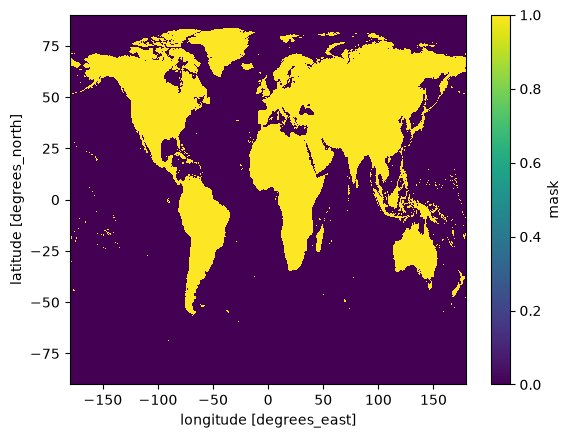

In [11]:
land_mask_u8.plot()

In [ ]:
# Note none of these fractions are area-weighted

# land_mask is otherwise recomputed (full coastline rasterization) on every .where() use below
land_mask = land_mask.compute()

summary_rows = []

for i, tag in enumerate(tags):
    [gcm, var, scenario, ens] = parse_tag(tag)

    group = f"{scenario}/{var}/{ens}"
    flags = xr.open_zarr(repos[gcm].readonly_session(BRANCH).store, group=group, consolidated=False)
    flag_time_varying = flags["flag_time_varying"]
    flag_time_invariant = flags["flag_time_invariant"]
    flag_time_varying_land = flag_time_varying * land_mask_u8
    flag_time_invariant_land = flag_time_invariant * land_mask_u8
    n_time = flag_time_varying.sizes["time"]

    # We calculate the land_frac means with sum() divided by n_land instead of
    # mean() with a mask so it goes quickly with the uint8 data type
    (
        frac_flagged_time_varying,
        frac_space_flagged_time_varying,
        frac_space_flagged_time_invariant,
        land_frac_flagged_time_varying,
        land_frac_space_flagged_time_varying,
        land_frac_space_flagged_time_invariant,
    ) = dask.compute(
        np.nanmean(flag_time_varying),
        np.nanmean(flag_time_varying.sum(dim="time") > 0),
        np.nanmean(flag_time_invariant),
        flag_time_varying_land.sum() / (n_land * n_time),
        (flag_time_varying_land.sum(dim="time") > 0).sum() / n_land,
        flag_time_invariant_land.sum() / n_land,
    )

    # Sanity check: these should each be 0 or 1
    # print(f"  check flag_time_varying max/min:   {np.nanmax(flag_time_varying)} / {np.nanmin(flag_time_varying)}")
    # print(f"  check flag_time_invariant max/min: {np.nanmax(flag_time_invariant)} / {np.nanmin(flag_time_invariant)}")

    print(f"{tag}:")
    print(
        f"  frac of dataset [time, lat, lon] flagged (time-varying):     {frac_flagged_time_varying:.4g}"
    )
    print(
        f"  frac of space [lat, lon] with >=1 flagged timestep:          {frac_space_flagged_time_varying:.4g}"
    )
    print(
        f"  frac of space [lat, lon] with time-invariant flag:           {frac_space_flagged_time_invariant:.4g}"
    )
    print(
        f"  land frac of dataset [time, lat, lon] flagged (time-varying):{land_frac_flagged_time_varying:.4g}"
    )
    print(
        f"  land frac of space [lat, lon] with >=1 flagged timestep:     {land_frac_space_flagged_time_varying:.4g}"
    )
    print(
        f"  land frac of space [lat, lon] with time-invariant flag:      {land_frac_space_flagged_time_invariant:.4g}"
    )

    summary_rows.append(
        {
            "tag": tag,
            "gcm": gcm,
            "variable": var,
            "scenario": scenario,
            "ensemble_member": ens,
            "frac_flagged_time_varying": float(frac_flagged_time_varying),
            "frac_space_flagged_time_varying": float(frac_space_flagged_time_varying),
            "frac_space_flagged_time_invariant": float(frac_space_flagged_time_invariant),
            "land_frac_flagged_time_varying": float(land_frac_flagged_time_varying),
            "land_frac_space_flagged_time_varying": float(land_frac_space_flagged_time_varying),
            "land_frac_space_flagged_time_invariant": float(land_frac_space_flagged_time_invariant),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_CSV, index=False)
summary_df

# C. Read in summary CSV and make summary figure

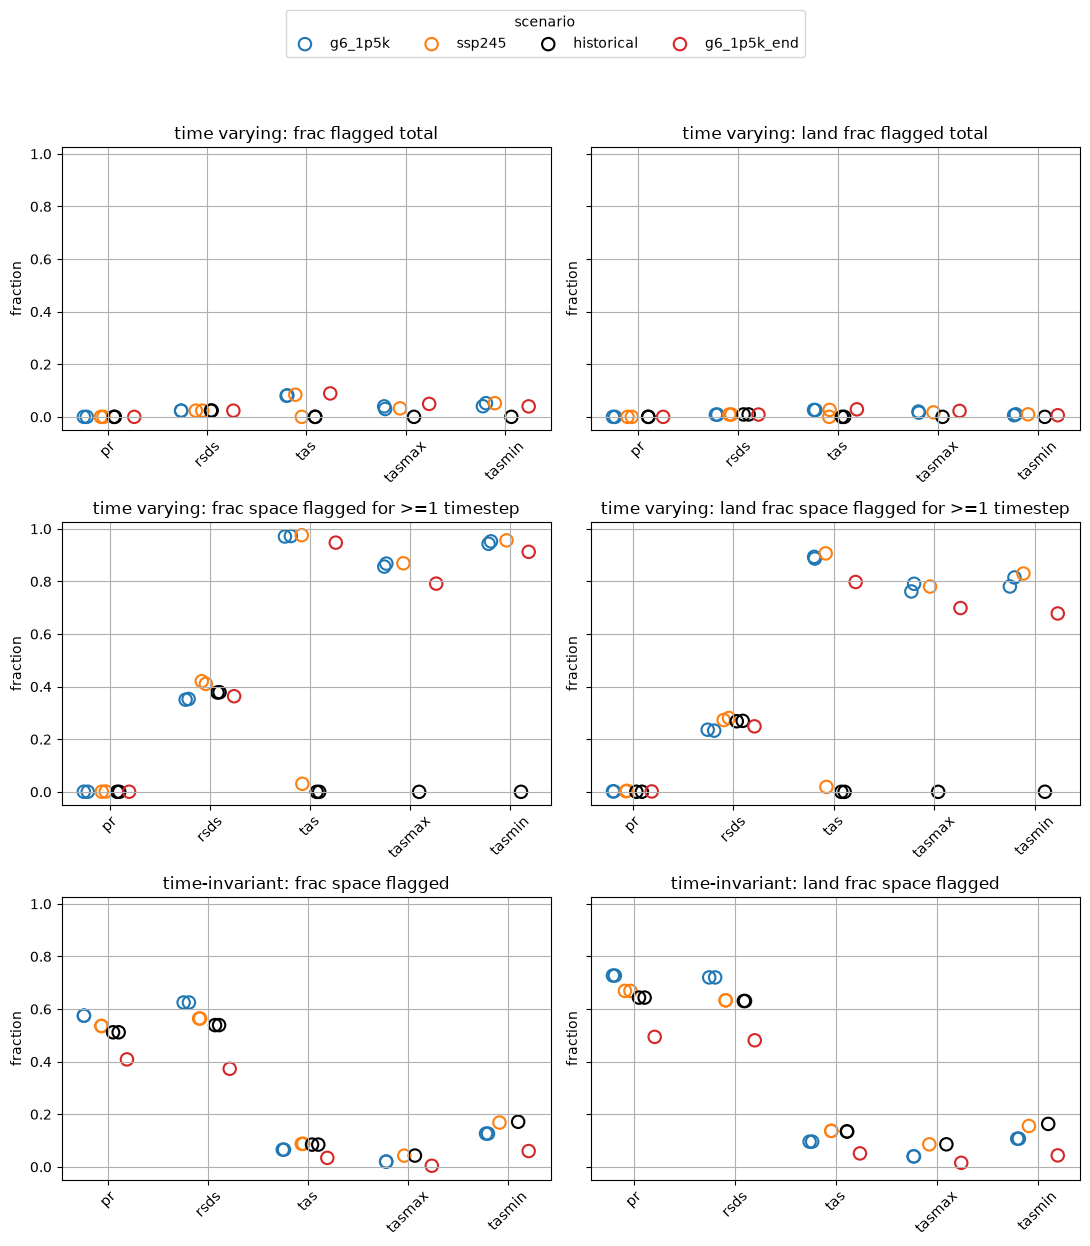

In [13]:
summary_df = pd.read_csv(SUMMARY_CSV)

metrics = [
    ("frac_flagged_time_varying", "time varying: frac flagged total"),
    ("land_frac_flagged_time_varying", "time varying: land frac flagged total"),
    ("frac_space_flagged_time_varying", "time varying: frac space flagged for >=1 timestep"),
    (
        "land_frac_space_flagged_time_varying",
        "time varying: land frac space flagged for >=1 timestep",
    ),
    ("frac_space_flagged_time_invariant", "time-invariant: frac space flagged"),
    ("land_frac_space_flagged_time_invariant", "time-invariant: land frac space flagged"),
]

VARIABLE_ORDER = ["pr", "rsds", "tas", "tasmax", "tasmin"]  # whatever order you want

variables = [v for v in VARIABLE_ORDER if v in summary_df["variable"].unique()]
scenarios = summary_df["scenario"].unique().tolist()

var_pos = {v: i for i, v in enumerate(variables)}
palette = dict(zip(scenarios, sns.color_palette(n_colors=len(scenarios))))
palette["historical"] = "black"

GROUP_SPREAD = 0.15  # distance between scenario clusters within a variable's x position
JITTER_WIDTH = 0.04  # random scatter within each scenario's own cluster

scenario_offset = {
    s: (i - (len(scenarios) - 1) / 2) * GROUP_SPREAD for i, s in enumerate(scenarios)
}

rng = np.random.default_rng(0)

fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharey=True)
axes = axes.flatten()

for ax, (col, label) in zip(axes, metrics):
    for s in scenarios:
        sub = summary_df[summary_df["scenario"] == s]
        x = (
            sub["variable"].map(var_pos)
            + scenario_offset[s]
            + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, len(sub))
        )
        ax.scatter(
            x,
            sub[col],
            marker="o",
            facecolors="none",
            edgecolors=palette[s],
            linewidths=1.5,
            s=80,
            label=s,
        )
    ax.set_xticks(range(len(variables)))
    ax.set_xticklabels(variables, rotation=45)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("fraction")
    ax.grid()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="scenario",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=len(scenarios),
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Zoom in on one example

In [14]:
tag = "CESM2-WACCM_pr_g6_1p5k_002"
[gcm, var, scenario, ens] = parse_tag(tag)
flags = xr.open_zarr(
    repos[gcm].readonly_session(BRANCH).store, group=f"{scenario}/{var}/{ens}", consolidated=False
)
flag_time_varying = flags["flag_time_varying"]
flag_time_invariant = flags["flag_time_invariant"]
flag_time_varying_land = flag_time_varying * land_mask_u8
flag_time_invariant_land = flag_time_invariant * land_mask_u8
n_time = flag_time_varying.sizes["time"]

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


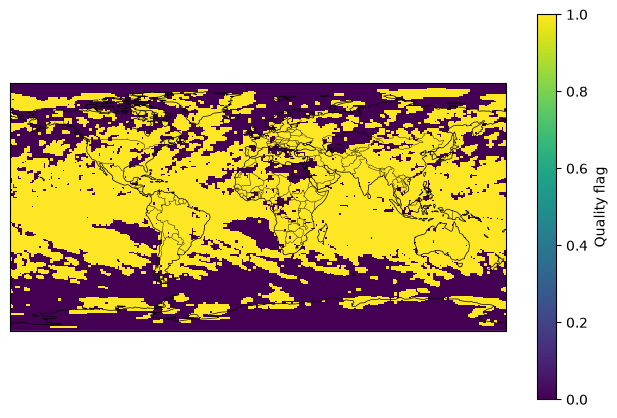

In [15]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
flag_time_invariant.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
plt.show()

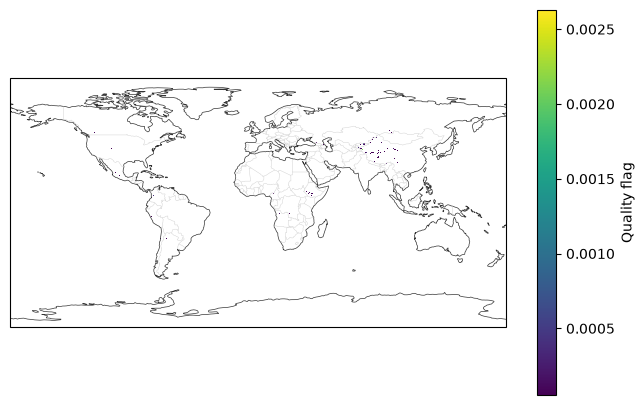

In [16]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
freq_flagged = flag_time_varying_land.mean(dim="time")
freq_flagged.where(freq_flagged > 0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.2")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.8")
plt.show()

Text(0, 0.5, 'Fraction of land grid cells flagged in 365-day window')

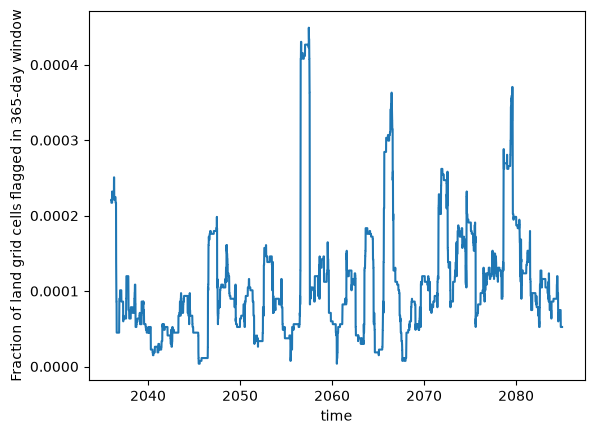

In [17]:
(flag_time_varying_land.sum(dim=["lat", "lon"]).rolling(time=365).sum() / n_land).plot()
plt.ylabel("Fraction of land grid cells flagged in 365-day window")